# Stellar Structure Calculation Working Notebook
#### Kieran Manjrawala

In [27]:
import pandas as pd
import numpy as np
import scipy
from scipy import io
import os

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
import glob
import random
from scipy.optimize import curve_fit

%matplotlib inline

import math
import datetime as dt
from scipy.optimize import brentq

import matplotlib as mpl

mpl.rcParams.update({
    # Fonts
    "font.family": "serif",
    "font.size": 18,

    # Axes
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "axes.linewidth": 2.0,

    # Ticks
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.size": 8,
    "xtick.major.width": 2,
    "xtick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.major.size": 8,
    "ytick.major.width": 2,
    "ytick.minor.size": 4,
    "ytick.minor.width": 1.5,

    # Ticks on all sides
    "ytick.right": True,

    # Lines
    "lines.linewidth": 2,

    # Legend
    "legend.fontsize": 10,
    "legend.frameon": False,
})

from PIL import Image
from scipy.signal import convolve2d
from scipy.ndimage import median_filter

import re
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import PchipInterpolator

import numpy as np
from astropy.io import ascii
from scipy import interpolate
import numpy.lib.recfunctions
from matplotlib.patches import Patch

### Stellar Structure Calculation in Step-Wise Order

In [2]:
'''
Initialize the relevant starting parameters. Corresponds to Step 1 of instructions
'''

G = 6.67430e-8                  # cgs
M_sun = 1.989e33                # g
R_sun = 6.957e10                # cm
L_sun = 3.828e33                # erg/s

M_star = 2.0 * M_sun 
X = 0.70                        # Hydrogen mass fraction
Y = 0.28                        # Helium mass fraction
Z = 1 - X - Y                   # Heavies mass fraction

q_fit = 0.3                     # Intermediate mass regime where solutions meet
q_inner = 1e-8                  # Part of mass near the core
q_outer = 1.0 - 1e-8            # Part of the mass near the outer envelope

m_fit = q_fit * M_star
m_inner = q_inner * M_star
m_outer = q_outer * M_star

In [3]:
'''
Equation of States calculation assuming complete ionization given pressure, temperature, and composition. 
Corresponds to Step 2 and Homework 2
'''

kB = 1.380649e-16         # erg/K 
R  = 8.314462618e7        # g
a_rad   = 7.5657e-15      # erg cm^-3 K^-4
c = 2.99792458e10         # cm/s
mH = 1.6735575e-24        # g
G = 6.67430e-8            # cgs
sigma_sb = 5.670374419e-5 # erg cm^-2 s^-1 K^-4

def compute_density(P, T, X, Y, Z = None):
    if Z is None:
        Z = 1 - X - Y
    
    P_rad = (a_rad/3) * T**4
    P_gas = P - P_rad

    mu = 1 / (2.0*X + 0.75*Y + 0.5*Z)
    
    rho = (mu * mH / kB) * (P_gas / T)

    beta = P_gas / P
    
    return rho, beta

In [4]:
'''

'''

opacity_table = "/Users/kmanj/Downloads/opacity_x0.7y0.28z0.02.txt"

def _load_opacity_table(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_start = None
    for i, line in enumerate(lines):
        if "logT" in line:
            header_start = i
            break

    data_start = header_start + 1
    table = ascii.read(filename, header_start=header_start, data_start=data_start)

    logR_grid = np.array([float(col) for col in table.colnames[1:]], dtype=float)
    logT_grid = np.array(table["logT"], dtype=float)

    opacity_grid = np.lib.recfunctions.structured_to_unstructured(table.as_array())
    opacity_grid = np.delete(opacity_grid, 0, axis=1)
    opacity_grid = np.array(opacity_grid, dtype=float)

    opacity_grid[opacity_grid > 8] = np.nan

    interp = RegularGridInterpolator(
        (logT_grid, logR_grid),
        opacity_grid,
        bounds_error=False,
        fill_value=np.nan
    )
    return interp, logT_grid, logR_grid

_opacity_interp, _logT_grid, _logR_grid = _load_opacity_table(opacity_table)

def get_opacity(T, rho):
    T   = np.maximum(10**3.75, T)    
    T6  = T * 1e-6
    R   = np.maximum(1e-8, rho / T6**3)

    logT_target = np.log10(T)
    logR_target = np.log10(R)

    if (logT_target < _logT_grid.min() or logT_target > _logT_grid.max() or
            logR_target < _logR_grid.min() or logR_target > _logR_grid.max()):
        return np.nan

    log_kappa = _opacity_interp([[logT_target, logR_target]])[0]
    return 10**log_kappa

In [5]:
'''

'''

def nuclear_energy_rates(rho, T, X, Y, psi=1.0, use_screening=True):
    Z = 1.0 - X - Y

    T7 = T / 1e7
    T9 = T / 1e9

   
    def zeta_mixture(X, Y):
        return 2.0*X + 1.5*Y

    if use_screening:
        zeta = zeta_mixture(X, Y)
        ED_over_kT = 5.92e-3 * np.sqrt((zeta * rho) / (T7**3))
        f11 = np.exp(ED_over_kT)
    else:
        f11 = 1.0

    g11 = 1 + 3.82*T9 + 1.51*T9**2 + 0.144*T9**3 - 0.0114*T9**4

    eps_pp = (2.57e4 * f11 * g11 *rho * X**2 *T9**(-2/3) *np.exp(-3.381 * T9**(-1/3)))

    g14_1 = 1 - 2.00*T9 + 3.41*T9**2 - 2.43*T9**3
    X_CNO = Z
    

    eps_cno = (8.24e25 * g14_1 * X_CNO * X * rho * T9**(-2/3) * np.exp(-15.231 * T9**(-1/3) - (T9/0.8)**2))

    eps_total = eps_pp + eps_cno
    
    return eps_pp, eps_cno, eps_total

In [6]:
'''
Helper functions for computing the nabla depending on efficient radiation transport
'''

def nabla_rad(l, P, T, m, kappa):
    return (3.0 * kappa * l * P) / (16.0 * np.pi * a_rad * c * G * m * T**4)


def nabla_ad(beta):
    return (8.0 - 6.0*beta) / (32.0 - 24.0*beta - 3.0*beta**2)


def actual_nabla(l, P, T, m, kappa, beta):
    grad_rad = nabla_rad(l, P, T, m, kappa)
    grad_ad = nabla_ad(beta)
    grad = min(grad_rad, grad_ad)

    if grad_rad < grad_ad:
        transport = "radiative"
    else:
        transport = "convective"

    return grad, grad_rad, grad_ad, transport
    

In [7]:
'''
Function that contains the ever-evaluating ODEs that will be solved
'''

def derivs(m, y, X, Y, Z):
    l, P, r, T = y

    rho, beta = compute_density(P, T, X, Y, Z)
    kappa = get_opacity(T, rho)

    eps_pp, eps_cno, eps = nuclear_energy_rates(rho, T, X, Y)
    grad, grad_rad, grad_ad, transport = actual_nabla(l, P, T, m, kappa, beta)

    dl_dm = eps
    dP_dm = -G * m / (4.0 * np.pi * r**4)
    dr_dm = 1.0 / (4.0 * np.pi * r**2 * rho)
    dT_dm = -(G * m * T / (4.0 * np.pi * r**4 * P)) * grad

    return np.array([dl_dm, dP_dm, dr_dm, dT_dm])

In [8]:
'''

'''

def load1(M, M_r, P_c, T_c, X, Y, Z):
    rho_c, beta_c = compute_density(P_c, T_c, X, Y, Z)
    eps_pp_c, eps_cno_c, epsilon_c = nuclear_energy_rates(rho_c, T_c, X, Y)

    r = (3 * M_r / (4 * np.pi * rho_c))**(1/3)

    l = epsilon_c * M_r

    P = P_c - (3 * G / (8 * np.pi)) * (4 * np.pi * rho_c / 3)**(4/3) * M_r**(2/3)

    kappa_c = get_opacity(T_c, rho_c)

    grad_rad_c = nabla_rad(l, P_c, T_c, M_r, kappa_c)
    grad_ad_c = nabla_ad(beta_c)

    if grad_rad_c <= grad_ad_c:
        T = (T_c**4 - (1 / (2 * a_rad * c)) * (3 / (4 * np.pi))**(2/3)* kappa_c * epsilon_c * rho_c**(4/3) * M_r**(2/3))**(1/4)
    else:
        lnT = np.log(T_c) - (np.pi / 6)**(1/3) * G * grad_ad_c * rho_c**(4/3) / P_c * M_r**(2/3)
        T = np.exp(lnT)

    return [l, P, r, T]




def load2(M, R, L, X, Y, Z):
    T = (L / (4 * np.pi * R**2 * sigma_sb))**(1/4)
    g = G * M / R**2

    def pressure_residual(logP):
        P = 10**logP
        rho, beta = compute_density(P, T, X, Y, Z)
        kappa = get_opacity(T, rho)
        if kappa is None or np.isnan(kappa) or kappa <= 0:
            return np.nan
        P_target = (2/3) * g / kappa
        return np.log10(P) - np.log10(P_target)

    logP_sol = brentq(pressure_residual, 3.0, 4.0, xtol=1e-10)
    P = 10**logP_sol

    return [L, P, R, T]

In [9]:
P_c_guess = 2.5e17
T_c_guess = 1.5e7
L_star_guess = 1.6 * L_sun
R_star_guess = 16.0 * R_sun

# small mass near center
M_r_inner = m_inner

# boundary values
y_inner = load1(M_star, M_r_inner, P_c_guess, T_c_guess, X, Y, Z)
y_outer = load2(M_star, R_star_guess, L_star_guess, X, Y, Z)

print("Inner boundary [l, P, r, T] =", y_inner)
print("Outer boundary [l, P, r, T] =", y_outer)

# derivatives at the boundaries
#dy_inner = derivs(M_r_inner, y_inner, X, Y, Z)
#dy_outer = derivs(M_star, y_outer, X, Y, Z)

#print("Inner boundary derivatives [dl/dm, dP/dm, dr/dm, dT/dm] =", dy_inner)
#print("Outer boundary derivatives [dl/dm, dP/dm, dr/dm, dT/dm] =", dy_outer)

Inner boundary [l, P, r, T] = [np.float64(1.4051821801650052e+27), 2.4999609692006474e+17, 42393796.19370008, np.float64(14999906.469433714)]
Outer boundary [l, P, r, T] = [6.124800000000001e+33, 2861.4477191851765, 1113120000000.0, 1622.918028674558]


In [10]:
m_inner = 1e-8 * M_star
m_fit   = 0.5 * M_star
m_outer = (1 - 1e-8) * M_star

In [11]:
from scipy.integrate import solve_ivp

def integrate_outward(Pc, Tc, Ls, Rs):
    y0 = load1(M_star, m_inner, Pc, Tc, X, Y, Z)

    sol = solve_ivp(
        lambda m, y: derivs(m, y, X, Y, Z),
        [m_inner, m_fit],
        y0,
        method="RK45",
        rtol=1e-8,
        atol=1e-10
    )
    return sol

In [12]:
def integrate_inward(Pc, Tc, Ls, Rs):
    y0 = load2(M_star, Rs, Ls, X, Y, Z)

    sol = solve_ivp(
        lambda m, y: derivs(m, y, X, Y, Z),
        [m_outer, m_fit],
        y0,
        method="RK45",
        rtol=1e-9,
        atol=1e-10
    )
    return sol

In [13]:
def residuals(log_guess):
    logPc, logTc, logLs, logRs = log_guess

    Pc = 10**logPc
    Tc = 10**logTc
    Ls = 10**logLs
    Rs = 10**logRs

    sol_out = integrate_outward(Pc, Tc, Ls, Rs)
    sol_in  = integrate_inward(Pc, Tc, Ls, Rs)

    y_out = sol_out.y[:, -1]
    y_in  = sol_in.y[:, -1]

    # use relative mismatches to help scaling
    return np.array([
    (y_out[0] - y_in[0]) / (0.5 * (abs(y_out[0]) + abs(y_in[0])) + 1e-30),
    (y_out[1] - y_in[1]) / (0.5 * (abs(y_out[1]) + abs(y_in[1])) + 1e-30),
    (y_out[2] - y_in[2]) / (0.5 * (abs(y_out[2]) + abs(y_in[2])) + 1e-30),
    (y_out[3] - y_in[3]) / (0.5 * (abs(y_out[3]) + abs(y_in[3])) + 1e-30),
])

In [14]:
from scipy.optimize import root

guess0 = np.array([
    np.log10(1.4e17),
    np.log10(2.0e7),    # right at the L crossover
    np.log10(16.4 * L_sun),
    np.log10(1.6 * R_sun),
])

sol_root = root(residuals, guess0, method="hybr", tol=1e-10,options={'factor': 0.001})
print(sol_root.success, sol_root.message)
print(sol_root.x)

True The solution converged.
[17.1761963   7.30490863 34.7231572  11.07607624]


In [15]:
Pc_sol = 10**sol_root.x[0]
Tc_sol = 10**sol_root.x[1]
Ls_sol = 10**sol_root.x[2]
Rs_sol = 10**sol_root.x[3]

print("Pc =", Pc_sol)
print("Tc =", Tc_sol)
print("L* =", Ls_sol)
print("R* =", Rs_sol)

Pc = 1.5003628491795658e+17
Tc = 20179417.702638514
L* = 5.286365715338471e+34
R* = 119145113700.1497


In [16]:
sol_out = integrate_outward(Pc_sol, Tc_sol, Ls_sol, Rs_sol)
sol_in  = integrate_inward(Pc_sol, Tc_sol, Ls_sol, Rs_sol)

In [17]:
m_out = sol_out.t
m_in  = sol_in.t[::-1]

y_out = sol_out.y
y_in  = sol_in.y[:, ::-1]

m_all = np.concatenate([m_out, m_in[1:]])
y_all = np.hstack([y_out, y_in[:, 1:]])

l_all = y_all[0]
P_all = y_all[1]
r_all = y_all[2]
T_all = y_all[3]

In [18]:
rho_all = []
eps_all = []
kappa_all = []
grad_ad_all = []
grad_all = []
transport_all = []

for m, l, P, r, T in zip(m_all, l_all, P_all, r_all, T_all):
    rho, beta = compute_density(P, T, X, Y, Z)
    kappa = get_opacity(T, rho)
    eps_pp, eps_cno, eps = nuclear_energy_rates(rho, T, X, Y)
    grad, grad_rad, grad_ad, transport = actual_nabla(l, P, T, m, kappa, beta)

    rho_all.append(rho)
    eps_all.append(eps)
    kappa_all.append(kappa)
    grad_ad_all.append(grad_ad)
    grad_all.append(grad)
    transport_all.append(transport)

In [21]:
print("Residuals at fitting point:", sol_root.fun)
print("Converged:", sol_root.success)

Residuals at fitting point: [ 1.13041771e-10  1.45338911e-08  1.12416670e-09 -2.60932975e-08]
Converged: True


In [22]:
print("Number of function evaluations:", sol_root.nfev)
print("Converged:", sol_root.success)
print("Message:", sol_root.message)

Number of function evaluations: 36
Converged: True
Message: The solution converged.


In [29]:
import pandas as pd
import numpy as np

# Build full DataFrame in physical units
df_full = pd.DataFrame({
    'm':np.array(m_all) / M_sun,
    'r':np.array(r_all) / R_sun,
    'rho':rho_all,
    'T':T_all,
    'P':P_all,
    'l':np.array(l_all) / L_sun,
    'eps':eps_all,
    'kappa':kappa_all,
    'nabla_ad':grad_ad_all,
    'nabla':grad_all,
    'transport':transport_all,
})

m_min = df_full['m'].min()
m_max = df_full['m'].max()

# Find the exact mass where outer convection begins
outer_conv_mask = (df_full['transport'] == 'convective') & (df_full['m'] > 1.0)
m_conv_start = df_full[outer_conv_mask]['m'].min()

# Three-zone sampling + forced outer convection zone rows
n_log  = 17
n_lin  = 160
n_surf = 50

m_log  = np.logspace(np.log10(m_min), np.log10(0.1 * m_max), n_log, endpoint=False)
m_lin  = np.linspace(0.1 * m_max, m_conv_start * 0.999, n_lin, endpoint=False)
m_surf = np.linspace(m_conv_start, m_max, n_surf)
m_vals = np.concatenate([m_log, m_lin, m_surf])

idx = [np.argmin(np.abs(df_full['m'].values - m)) for m in m_vals]
df_sample = df_full.iloc[idx].drop_duplicates(subset='m').reset_index(drop=True)

df_sample.to_csv('/Users/kmanj/mesa_work/structure_table.csv', index=False)
print(f"Saved {len(df_sample)} rows to structure_table.csv")
print("\nTransport zone counts:")
print(df_sample['transport'].value_counts())
print("\nOuter convective rows:")
print(df_sample[df_sample['transport'] == 'convective'][['m', 'r', 'T', 'rho']].tail(10).to_string())

Saved 121 rows to structure_table.csv

Transport zone counts:
transport
radiative     78
convective    43
Name: count, dtype: int64

Outer convective rows:
       m         r             T           rho
107  2.0  1.711139  13480.308119  6.020871e-09
108  2.0  1.711267  12995.530242  5.689942e-09
109  2.0  1.711390  12528.070315  5.377559e-09
110  2.0  1.711508  12077.321342  5.082650e-09
111  2.0  1.711623  11642.695174  4.804205e-09
112  2.0  1.711733  11223.626417  4.541278e-09
113  2.0  1.711839  10819.573566  4.292984e-09
114  2.0  1.711941  10429.972613  4.058465e-09
115  2.0  1.712039  10054.355418  3.836962e-09
116  2.0  1.712134   9692.410156  3.627837e-09


In [30]:
df_sample

,m,r,rho,T,P,l,eps,kappa,nabla_ad,nabla,transport
0,2.000000e-08,0.000798,5.547733e+01,2.017935e+07,1.500350e+17,0.000005,4.608948e+02,0.781302,0.396712,0.396712,convective
1,5.656363e-08,0.001129,5.547704e+01,2.017928e+07,1.500336e+17,0.000014,4.608654e+02,0.781305,0.396712,0.396712,convective
2,1.228658e-07,0.001462,5.547664e+01,2.017918e+07,1.500318e+17,0.000029,4.608257e+02,0.781309,0.396712,0.396712,convective
3,3.495702e-07,0.002071,5.547564e+01,2.017894e+07,1.500274e+17,0.000084,4.607266e+02,0.781319,0.396712,0.396712,convective
4,9.929536e-07,0.002933,5.547364e+01,2.017846e+07,1.500184e+17,0.000238,4.605280e+02,0.781338,0.396712,0.396712,convective
...,...,...,...,...,...,...,...,...,...,...,...
116,2.000000e+00,1.712134,3.627837e-09,9.692410e+03,4.721600e+03,13.809733,1.383154e-70,21.247382,0.394504,0.394504,convective
117,2.000000e+00,1.712261,3.351821e-09,9.207373e+03,4.142652e+03,13.809733,8.569568e-72,12.140089,0.394889,0.366628,radiative
118,2.000000e+00,1.712357,3.123334e-09,8.918560e+03,3.738765e+03,13.809733,1.456815e-72,8.521086,0.395011,0.263823,radiative
119,2.000000e+00,1.712440,2.909805e-09,8.734642e+03,3.411453e+03,13.809733,4.417132e-73,6.387221,0.394971,0.196128,radiative


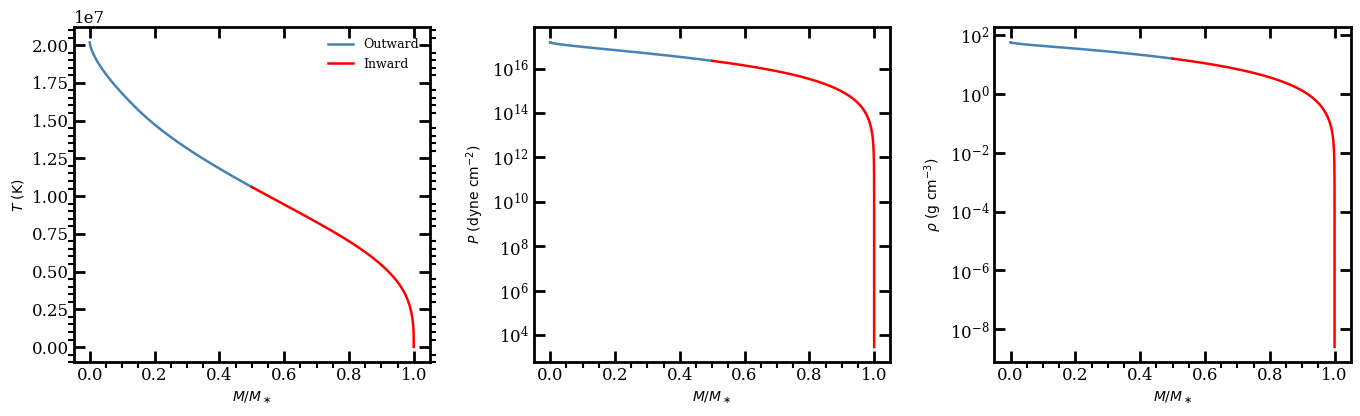

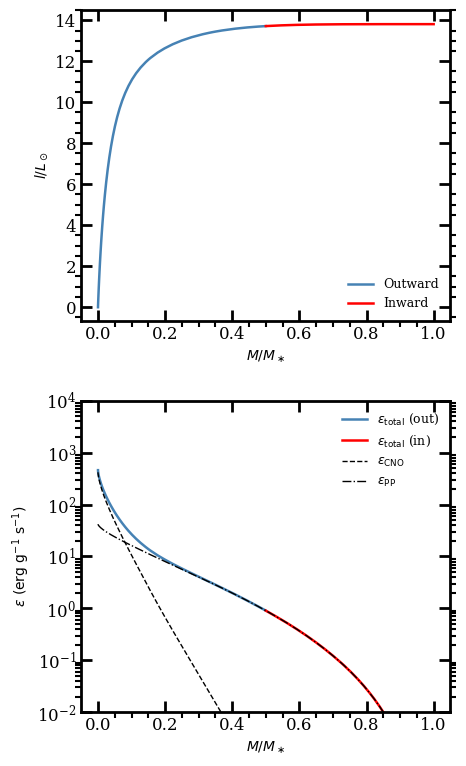

In [42]:



rho_all    = np.array(rho_all)
eps_all    = np.array(eps_all)
grad_all   = np.array(grad_all)
grad_ad_all = np.array(grad_ad_all)

n_out = len(sol_out.t)
q = m_all / M_star

# Color scheme
c_out = 'steelblue'
c_in  = 'red'  
lw = 1.8

def plot_split(ax, y, log=False):
    plot_fn = ax.semilogy if log else ax.plot
    ax.plot(q[:n_out],  y[:n_out],  color=c_out, lw=lw, label='Outward')
    plot_fn(q[n_out-1:], y[n_out-1:], color=c_in,  lw=lw, label='Inward')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plt.subplots_adjust(wspace=0.35)

plot_split(axes[0], T_all)
axes[0].set_xlabel(r"$M/M_\ast$")
axes[0].set_ylabel(r"$T\ ({\rm K})$")
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].minorticks_on()
axes[0].legend(fontsize=9)

plot_split(axes[1], P_all, log=True)
axes[1].set_xlabel(r"$M/M_\ast$")
axes[1].set_ylabel(r"$P\ ({\rm dyne\ cm^{-2}})$")
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].minorticks_on()

plot_split(axes[2], rho_all, log=True)
axes[2].set_xlabel(r"$M/M_\ast$")
axes[2].set_ylabel(r"$\rho\ ({\rm g\ cm^{-3}})$")
axes[2].tick_params(direction='in', top=True, right=True)
axes[2].minorticks_on()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(5, 8))

axes[0].plot(q[:n_out],   np.array(l_all[:n_out]) / L_sun,   color=c_out, lw=lw, label='Outward')
axes[0].plot(q[n_out-1:], np.array(l_all[n_out-1:]) / L_sun, color=c_in,  lw=lw, label='Inward')
axes[0].set_xlabel(r"$M/M_\ast$")
axes[0].set_ylabel(r"$l/L_\odot$")
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].minorticks_on()
axes[0].legend(fontsize=9)

axes[1].semilogy(q[:n_out],   eps_all[:n_out],   color=c_out,   lw=lw,                  label=r'$\epsilon_\mathrm{total}$ (out)')
axes[1].semilogy(q[n_out-1:], eps_all[n_out-1:], color=c_in,    lw=lw,                  label=r'$\epsilon_\mathrm{total}$ (in)')
axes[1].semilogy(q,           eps_cno_arr,        color='black', lw=1, linestyle='--',  label=r'$\epsilon_\mathrm{CNO}$')
axes[1].semilogy(q,           eps_pp_arr,         color='black', lw=1, linestyle='-.',  label=r'$\epsilon_\mathrm{PP}$')
axes[1].set_xlabel(r"$M/M_\ast$")
axes[1].set_ylabel(r"$\epsilon\ ({\rm erg\ g^{-1}\ s^{-1}})$")
axes[1].set_ylim(1e-2, 1e4)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].minorticks_on()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
print(eps_all[:5])
print(eps_cno_arr[:5])
print(eps_pp_arr[:5])

[460.89476338 460.89476338 460.89476338 460.89476338 460.89476338]
[418.97251832 418.97251832 418.97251832 418.97251832 418.97251832]
[41.92224506 41.92224506 41.92224506 41.92224506 41.92224506]


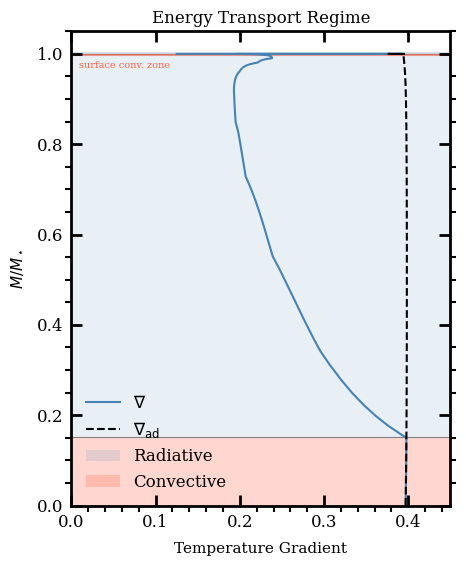

In [28]:
q             = np.array(m_all) / np.array(m_all).max()
nabla         = np.array(grad_all)
nabla_ad      = np.array(grad_ad_all)
transport_arr = np.array(transport_all)

conv_mask = transport_arr == 'convective'
rad_mask  = transport_arr == 'radiative'

def get_regions_q(mask, q):
    regions = []
    in_region = False
    for i, val in enumerate(mask):
        if val and not in_region:
            start = q[i-1] + 0.5*(q[i]-q[i-1]) if i > 0 else q[i]
            in_region = True
        elif not val and in_region:
            end = q[i-1] + 0.5*(q[i]-q[i-1])
            regions.append((start, end))
            in_region = False
    if in_region:
        regions.append((start, 1.0))
    return regions

fig, ax = plt.subplots(figsize=(5, 6))

for q0, q1 in get_regions_q(rad_mask, q):
    ax.axhspan(q0, q1+0.005, color='steelblue', alpha=0.12, lw=0, zorder=0)

for q0, q1 in get_regions_q(conv_mask, q):
    ax.axhspan(q0, q1, color='tomato', alpha=0.25, lw=0, zorder=0)

transitions = np.where(np.diff(conv_mask.astype(int)) != 0)[0]
for t in transitions:
    ax.axhline(q[t] + 0.5*(q[t+1]-q[t]), color='gray', lw=0.8, zorder=1)

# surface convective shell marker
ax.axhline(0.9984, color='tomato', lw=1.5, alpha=0.6, zorder=1)
ax.annotate('surface conv. zone', xy=(0.02, 0.965),xycoords=('axes fraction', 'data'),va='bottom', ha='left', fontsize=7, color='tomato')

ax.plot(nabla, q, color='steelblue', lw=1.5, label=r'$\nabla$', zorder=2)
ax.plot(nabla_ad, q, color='black', linestyle='--', lw=1.5,label=r'$\nabla_{\rm ad}$', zorder=2)

ax.tick_params(direction='in', top=True, right=True, pad=6)
ax.set_xlabel('Temperature Gradient', labelpad=8, fontsize = 11)
ax.set_ylabel(r'$M/M_\star$', labelpad=8, fontsize = 11)
ax.set_title('Energy Transport Regime', fontsize = 12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 0.45)
ax.tick_params(direction='in', top=True, right=True)
ax.minorticks_on()

handles = [
    plt.Line2D([], [], color='steelblue', lw=1.5, label=r'$\nabla$'),
    plt.Line2D([], [], color='black', linestyle='--', lw=1.5, label=r'$\nabla_{\rm ad}$'),
    Patch(facecolor='steelblue', alpha=0.15, label='Radiative'),
    Patch(facecolor='tomato',    alpha=0.25, label='Convective'),
]
ax.legend(handles=handles, loc='lower left', fontsize = 12)
plt.tight_layout()
plt.show()